In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [2]:
df= joblib.load(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl")

In [3]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [4]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    144 non-null    int64  
 1   month          144 non-null    int32  
 2   quater         144 non-null    int32  
 3   lag1           143 non-null    float64
 4   lag2           142 non-null    float64
 5   lag3           141 non-null    float64
 6   rolling_mean3  142 non-null    float64
 7   rolling_std3   142 non-null    float64
 8   rolling_mean6  139 non-null    float64
 9   rolling_std6   139 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 11.2 KB
None


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
count,144.000000,144.000000,144.000000,143.000000,142.000000,141.000000,142.000000,142.000000,139.000000,139.000000
mean,280.298611,6.500000,2.500000,279.237762,278.457746,277.163121,280.500000,24.125941,280.151079,34.415635
std,119.966317,3.464102,1.121936,119.708270,119.766772,119.192439,116.940083,17.180862,111.943814,20.641465
min,104.000000,1.000000,1.000000,104.000000,104.000000,104.000000,112.333333,1.154701,119.666667,8.916277
25%,180.000000,3.750000,1.750000,180.000000,180.000000,180.000000,184.916667,12.013857,182.416667,18.978871
50%,265.500000,6.500000,2.500000,264.000000,264.000000,264.000000,261.666667,20.219624,259.166667,26.515404
75%,360.500000,9.250000,3.250000,359.500000,358.250000,356.000000,357.666667,31.873737,362.416667,46.286518
max,622.000000,12.000000,4.000000,622.000000,622.000000,622.000000,587.666667,76.872188,534.000000,94.200672


In [5]:
print(df.index.freq)
print(df.index.dtype)
print(df.shape)
print(df.isnull().sum())
print(df.index.duplicated().sum())
df.bfill(inplace=True)
print(df.isnull().sum())
print(df.shape)

<MonthBegin>
datetime64[ns]
(144, 10)
#Passengers      0
month            0
quater           0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0
#Passengers      0
month            0
quater           0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64
(144, 10)


In [6]:
train=  np.log(df.iloc[:-12, :])
test= df.iloc[-12:, :]

In [7]:
print(train.index.freq)
print(train.index.dtype)
print(train.shape)
print(train.isnull().sum())
print(train.index.duplicated().sum())

<MonthBegin>
datetime64[ns]
(132, 10)
#Passengers      0
month            0
quater           0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64
0


In [8]:
test.shape

(12, 10)

In [9]:
train.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,4.718499,0.000000,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-02-01,4.770685,0.693147,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-03-01,4.882802,1.098612,0.000000,4.770685,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-04-01,4.859812,1.386294,0.693147,4.882802,4.770685,4.718499,4.838924,1.997569,4.824306,2.187879
1949-05-01,4.795791,1.609438,0.693147,4.859812,4.882802,4.770685,4.846808,1.738049,4.824306,2.187879


# ARIMA

Stationarity was checked explicitly in `main.ipynb` (ADF  before and after differencing)the test agreed  the raw series is non-stationary and a first difference is needed, consistent with the `d=1` that `auto_arima` selects below on its own via its internal stationarity search.

In [10]:
arima= auto_arima(
  train['#Passengers'],
  seasonal=False
)

In [11]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(1, 1, 5)   Log Likelihood                 138.569
Date:                Fri, 21 Aug 2026   AIC                           -261.138
Time:                        12:40:14   BIC                           -238.137
Sample:                    01-01-1949   HQIC                          -251.792
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0045      0.002      2.787      0.005       0.001       0.008
ar.L1          0.5542      0.138      4.004      0.000       0.283       0.826
ma.L1         -0.5912      0.102     -5.794      0.000      -0.791      -0.391
ma.L2         -0.2635      0.079     -3.330      0.001      -0.419      -0.108
ma.L3         -0.3491      0.090     -3.878      0.000      -0.526      -0.173
ma.L4         -0.3937      0.092     -4.290      0.000      -0.574      -0.214
ma.L5          0.7382      0.091      8.115      0.000       0.560       0.916
sigma2         0.0068      0.001      6.514      0.000       0.005       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 3.47
Prob(Q):                              0.75   Prob(JB):                         0.18
Heteroskedasticity (H):               1.11   Skew:                             0.35
Prob(H) (two-sided):                  0.73   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
arima_forecast= arima.predict(len(test))
arima_forecast= np.exp(arima_forecast)
arima_forecast

1960-01-01    441.824891
1960-02-01    443.182662
1960-03-01    463.493181
1960-04-01    463.470023
1960-05-01    471.230129
1960-06-01    477.752563
1960-07-01    483.598527
1960-08-01    489.086400
1960-09-01    494.395901
1960-10-01    499.628271
1960-11-01    504.840549
1960-12-01    510.064945
Freq: MS, dtype: float64

In [13]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

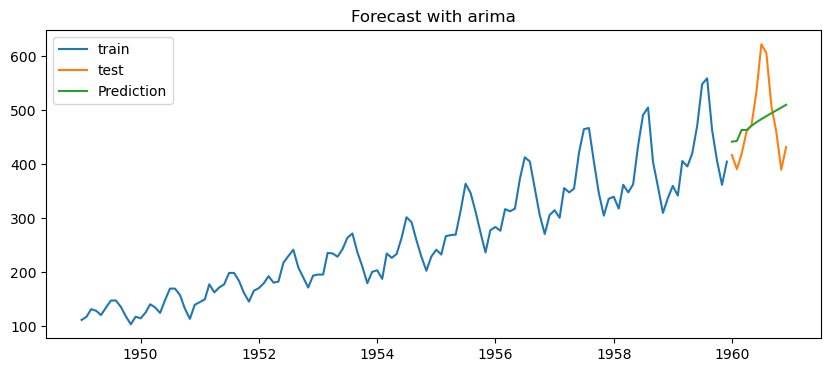

mean absolute error: 56.87
mean absolute percentage error: 12.0%
r2 score: 0.06
root mean squared error: 72.1


,mae,mape,r2,rmse
0,56.87,12.0,0.06,72.1


In [14]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],arima_forecast, 'arima')

# Sarima

In [15]:
sarima= auto_arima(train['#Passengers'],
                   seasonal=True,
                   m=12)

In [16]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  132
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 229.026
Date:                              Fri, 21 Aug 2026   AIC                           -448.052
Time:                                      12:42:59   BIC                           -434.114
Sample:                                  01-01-1949   HQIC                          -442.392
                                       - 12-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0193      0.009      2.159      0.031       0.002       0.037
ar.L1          0.6005      0.083      7.277      0.000       0.439       0.762
ar.L2          0.2412      0.085      2.847      0.004       0.075       0.407
ma.S.L12      -0.5672      0.105     -5.419      0.000      -0.772      -0.362
sigma2         0.0012      0.000      8.194      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.10
Prob(Q):                              1.00   Prob(JB):                         0.05
Heteroskedasticity (H):               0.36   Skew:                             0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
sarima_forecast= sarima.predict(len(test))
sarima_forecast= np.exp(sarima_forecast)
sarima_forecast

1960-01-01    421.610357
1960-02-01    402.052863
1960-03-01    470.789693
1960-04-01    459.103790
1960-05-01    478.530593
1960-06-01    553.776403
1960-07-01    630.177169
1960-08-01    638.564443
1960-09-01    534.326715
1960-10-01    469.188365
1960-11-01    412.874467
1960-12-01    459.488309
Freq: MS, dtype: float64

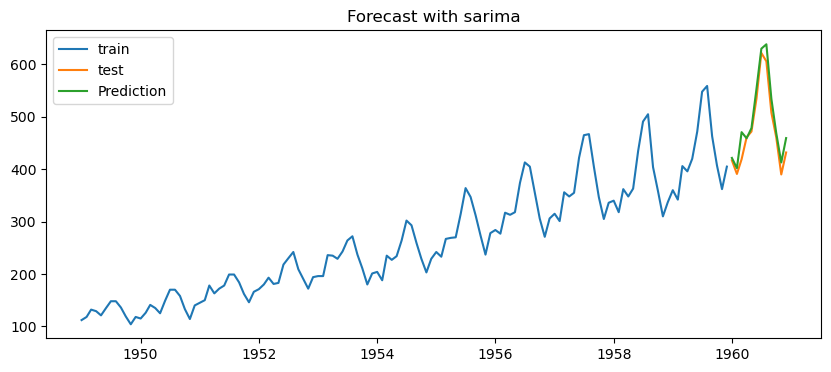

mean absolute error: 18.36
mean absolute percentage error: 4.0%
r2 score: 0.9
root mean squared error: 23.08


,mae,mape,r2,rmse
0,18.36,4.0,0.9,23.08


In [18]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],sarima_forecast, 'sarima')

# Sarimax

In [19]:
exog_train= train.drop(columns='#Passengers')
exog_test= test.drop(columns='#Passengers')

In [20]:
sarimax= auto_arima(train['#Passengers'],
                    X= exog_train,
                    m=12,
                    seasonal=True,
                    )

In [21]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(1, 0, 2)x(2, 0, 2, 12)   Log Likelihood                 368.916
Date:                            Fri, 21 Aug 2026   AIC                           -703.832
Time:                                    12:48:50   BIC                           -654.825
Sample:                                01-01-1949   HQIC                          -683.918
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
month             0.0313      0.018      1.758      0.079      -0.004       0.066
quater           -0.0476      0.025     -1.920      0.055      -0.096       0.001
lag1             -0.8411      0.044    -19.312      0.000      -0.926      -0.756
lag2             -0.8326      0.057    -14.724      0.000      -0.943      -0.722
lag3             -0.0443      0.061     -0.720      0.471      -0.165       0.076
rolling_mean3     2.5703      0.173     14.887      0.000       2.232       2.909
rolling_std3     -0.0041      0.005     -0.873      0.383      -0.013       0.005
rolling_mean6     0.1308      0.188      0.697      0.486      -0.237       0.498
rolling_std6      0.0214      0.018      1.188      0.235      -0.014       0.057
ar.L1             0.5815      0.133      4.370      0.000       0.321       0.842
ma.L1             0.6046      0.146      4.132      0.000       0.318       0.891
ma.L2            -0.0176      0.149     -0.118      0.906      -0.310       0.275
ar.S.L12          0.5265      1.250      0.421      0.674      -1.923       2.976
ar.S.L24          0.1636      1.048      0.156      0.876      -1.891       2.218
ma.S.L12         -0.2208      1.279     -0.173      0.863      -2.727       2.285
ma.S.L24          0.0490      0.691      0.071      0.944      -1.306       1.404
sigma2            0.0002   3.08e-05      7.203      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   4.16   Jarque-Bera (JB):               797.45
Prob(Q):                              0.04   Prob(JB):                         0.00
Heteroskedasticity (H):               0.08   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
sarimax_forecast= sarimax.predict(len(test), X= np.log(exog_test))
sarimax_forecast= np.exp(sarimax_forecast)
sarimax_forecast

1960-01-01    415.628389
1960-02-01    390.835028
1960-03-01    416.909005
1960-04-01    451.452847
1960-05-01    465.916454
1960-06-01    530.857534
1960-07-01    612.632372
1960-08-01    601.858771
1960-09-01    508.876575
1960-10-01    458.314157
1960-11-01    395.225255
1960-12-01    434.317493
Freq: MS, dtype: float64

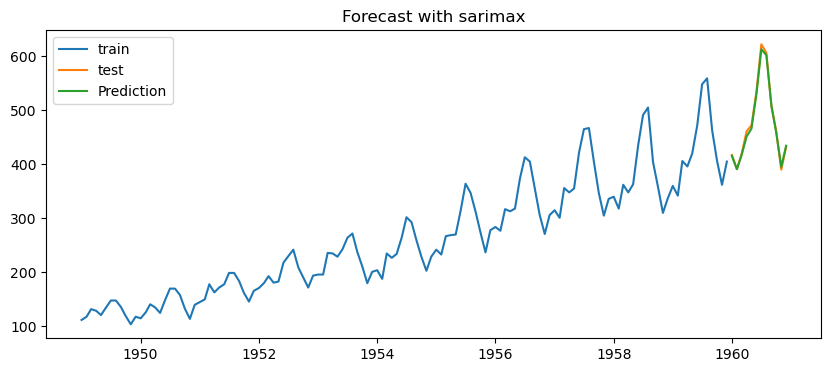

mean absolute error: 4.0
mean absolute percentage error: 1.0%
r2 score: 1.0
root mean squared error: 4.98


,mae,mape,r2,rmse
0,4.0,1.0,1.0,4.98


In [23]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],sarimax_forecast, 'sarimax')

In [24]:
# Fine tunning 


fine_tuned_model = auto_arima(
    train['#Passengers'],
    X=exog_train,
    m=12,
    seasonal=True,
    start_P=0, max_P=5,
    start_q=0, max_q=5,
    start_p=0, max_p=5,
    start_Q=0, max_Q=5,
    maxiter=1000,
    stepwise=True,
    trace=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-632.155, Time=1.69 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-706.176, Time=13.76 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-700.364, Time=15.06 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-633.238, Time=0.87 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-708.070, Time=8.84 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=-706.204, Time=25.36 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=-718.514, Time=30.05 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=-725.189, Time=50.48 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=64.82 sec
 ARIMA(1,0,0)(3,0,1)[12] intercept   : AIC=-723.688, Time=195.71 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=-730.039, Time=91.50 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=88.29 sec
 ARIMA(1,0,0)(3,0,2)[12] intercept   : AIC=inf, Time=211.77 sec
 ARIMA(1,0,0)(2,0,3)[12] intercept   : AIC=inf, Time=248.68 sec
 ARIMA(1,0,0)(1,0,3)[12] 

In [25]:
fine_tuned_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  132
Model:             SARIMAX(1, 0, 1)x(2, 0, [1, 2], 12)   Log Likelihood                 386.591
Date:                                 Fri, 21 Aug 2026   AIC                           -741.182
Time:                                         14:29:14   BIC                           -695.057
Sample:                                     01-01-1949   HQIC                          -722.439
                                          - 12-01-1959                                         
Covariance Type:                                   opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
month             0.0291      0.032      0.900      0.368      -0.034       0.092
quater           -0.0487      0.057     -0.850      0.395      -0.161       0.064
lag1             -0.8863      0.028    -32.136      0.000      -0.940      -0.832
lag2             -0.8756      0.039    -22.381      0.000      -0.952      -0.799
lag3             -0.1566      0.029     -5.389      0.000      -0.213      -0.100
rolling_mean3     2.2006      0.087     25.270      0.000       2.030       2.371
rolling_std3     -0.0075      0.003     -2.781      0.005      -0.013      -0.002
rolling_mean6     0.7020      0.110      6.373      0.000       0.486       0.918
rolling_std6      0.0192      0.009      2.210      0.027       0.002       0.036
ar.L1             0.8327      0.035     23.642      0.000       0.764       0.902
ma.L1             0.5244      0.086      6.116      0.000       0.356       0.692
ar.S.L12          0.3145      0.110      2.856      0.004       0.099       0.530
ar.S.L24          0.5206      0.122      4.250      0.000       0.281       0.761
ma.S.L12          0.5121      0.143      3.577      0.000       0.231       0.793
ma.S.L24          0.7774      0.316      2.461      0.014       0.158       1.396
sigma2            0.0001   3.11e-05      3.524      0.000    4.87e-05       0.000
===================================================================================
Ljung-Box (L1) (Q):                   2.62   Jarque-Bera (JB):                77.97
Prob(Q):                              0.11   Prob(JB):                         0.00
Heteroskedasticity (H):               0.20   Skew:                            -0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
fine_tuned_model.get_params

<bound method BaseEstimator.get_params of ARIMA(maxiter=1000, order=(1, 0, 1), scoring_args={},
      seasonal_order=(2, 0, 2, 12), suppress_warnings=True,
      with_intercept=False)>

In [27]:
forecast= fine_tuned_model.predict(n_periods=len(test), X= np.log(exog_test))
forecast= np.exp(forecast)
forecast

1960-01-01    418.857631
1960-02-01    394.939754
1960-03-01    423.099013
1960-04-01    462.189900
1960-05-01    473.757019
1960-06-01    532.925425
1960-07-01    612.764660
1960-08-01    609.410211
1960-09-01    510.151464
1960-10-01    460.259219
1960-11-01    396.447824
1960-12-01    435.782251
Freq: MS, dtype: float64

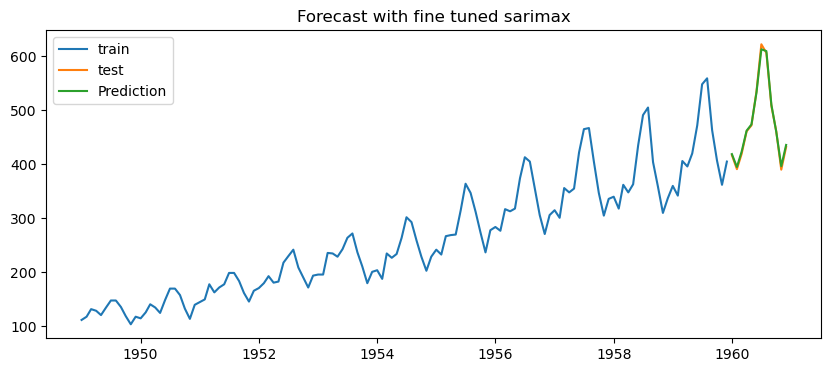

mean absolute error: 3.39
mean absolute percentage error: 1.0%
r2 score: 1.0
root mean squared error: 4.11


In [28]:
sarimax_metric=model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],forecast, 'fine tuned sarimax')

In [29]:
sarimax_metric.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\sarimax_metric.csv')

In [30]:

df_exog= df.drop(columns='#Passengers')
df_exog= np.log(df_exog)
df1= df.copy()
df1= np.log(df1)
df1.head()

,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,4.718499,0.000000,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-02-01,4.770685,0.693147,0.000000,4.718499,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-03-01,4.882802,1.098612,0.000000,4.770685,4.718499,4.718499,4.793032,2.328565,4.824306,2.187879
1949-04-01,4.859812,1.386294,0.693147,4.882802,4.770685,4.718499,4.838924,1.997569,4.824306,2.187879
1949-05-01,4.795791,1.609438,0.693147,4.859812,4.882802,4.770685,4.846808,1.738049,4.824306,2.187879


In [44]:
# Future prediction model
# "The final model order was selected based on the lowest AIC obtained during the fine-tuning search."

final_model= ARIMA(order=(1, 0, 2), seasonal_order=(2, 0, 2, 12),maxiter=2000, suppress_warnings=True)



In [45]:
final_model.fit(y=df1['#Passengers'], X=df_exog)

ARIMA(maxiter=2000, order=(1, 0, 2), seasonal_order=(2, 0, 2, 12),
      suppress_warnings=True)

In [46]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(1, 0, 2)x(2, 0, 2, 12)   Log Likelihood                 426.720
Date:                            Fri, 21 Aug 2026   AIC                           -817.439
Time:                                    14:36:49   BIC                           -763.982
Sample:                                01-01-1949   HQIC                          -795.717
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -0.0002      0.007     -0.025      0.980      -0.013       0.013
month             0.0330      0.035      0.952      0.341      -0.035       0.101
quater           -0.0469      0.059     -0.794      0.427      -0.163       0.069
lag1             -0.8804      0.027    -32.227      0.000      -0.934      -0.827
lag2             -0.8774      0.039    -22.267      0.000      -0.955      -0.800
lag3             -0.1487      0.026     -5.779      0.000      -0.199      -0.098
rolling_mean3     2.2158      0.078     28.494      0.000       2.063       2.368
rolling_std3     -0.0080      0.003     -2.924      0.003      -0.013      -0.003
rolling_mean6     0.6709      0.112      6.013      0.000       0.452       0.890
rolling_std6      0.0227      0.008      2.979      0.003       0.008       0.038
ar.L1             0.8724      0.035     24.878      0.000       0.804       0.941
ma.L1             0.3997      0.119      3.348      0.001       0.166       0.634
ma.L2            -0.2008      0.102     -1.966      0.049      -0.401      -0.001
ar.S.L12          0.3323      0.097      3.422      0.001       0.142       0.523
ar.S.L24          0.5107      0.107      4.768      0.000       0.301       0.721
ma.S.L12          0.5128      0.124      4.147      0.000       0.270       0.755
ma.S.L24          0.8254      0.349      2.362      0.018       0.141       1.510
sigma2            0.0001    3.1e-05      3.296      0.001    4.14e-05       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.95   Jarque-Bera (JB):               101.83
Prob(Q):                              0.33   Prob(JB):                         0.00
Heteroskedasticity (H):               0.25   Skew:                            -0.06
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [47]:
last_date= df.index[-1]
last_date

Timestamp('1960-12-01 00:00:00')

In [48]:
period= 12

future_dates= pd.date_range(
  start=last_date + pd.DateOffset(months=1),
  periods=period ,
  freq='MS'
)

In [49]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [50]:
future_data= pd.DataFrame(index=future_dates)

In [51]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_dates:

        month_number = np.log(date.month)
        quarter_number = np.log(date.quarter)

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]


        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

      

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
           
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(n_periods=1, X=one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_dates, name=target_col)

    return future_exog, forecast

In [52]:
history = df1["#Passengers"]

future_exog, forecast = build_exog_row(final_model, history, future_data)


In [53]:
future_exog.head()

,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
1961-01-01,0.000000,0.000000,6.068426,5.966147,6.133398,6.055990,0.084316,6.206379,0.186644
1961-02-01,0.693147,0.000000,6.095690,6.068426,5.966147,6.043421,0.068296,6.150170,0.152411
1961-03-01,1.098612,0.000000,5.963443,6.095690,6.068426,6.042520,0.069826,6.076264,0.102314
1961-04-01,1.386294,0.693147,6.001387,5.963443,6.095690,6.020173,0.068096,6.038082,0.071298
1961-05-01,1.609438,0.693147,5.981125,6.001387,5.963443,5.981985,0.018986,6.012703,0.056056


In [54]:
forecast =np.exp(forecast)
forecast


1961-01-01    443.940454
1961-02-01    388.946961
1961-03-01    403.988632
1961-04-01    395.885590
1961-05-01    361.797832
1961-06-01    374.937686
1961-07-01    362.309896
1961-08-01    337.183246
1961-09-01    345.402510
1961-10-01    331.446954
1961-11-01    313.173185
1961-12-01    317.860367
Freq: MS, Name: #Passengers, dtype: float64

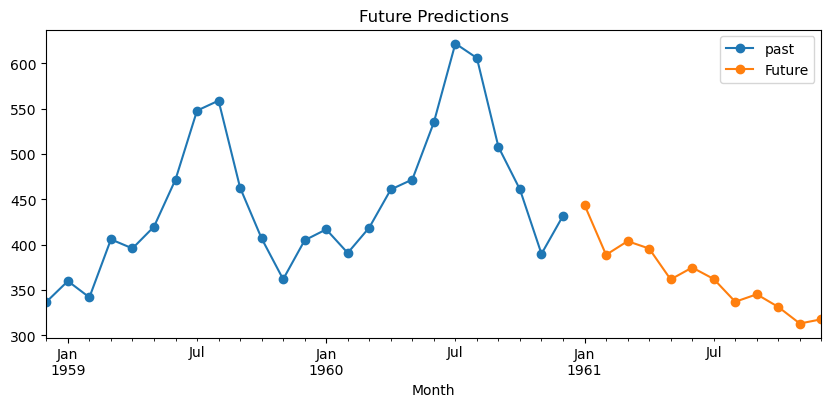

In [55]:
plt.figure(figsize=(10,4))
df['#Passengers'].iloc[-25:].plot(label='past',marker='o')
forecast.plot(label='Future', marker='o')

plt.legend()
plt.title('Future Predictions')
plt.show()

In [56]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\sarimax.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\sarimax.pkl']